# Section 1.6 — Resource Availabilities

> **Basic.** Build a model that simulates resource availabilities based on an interval, e.g. a two-week interval.
>
> **Advanced.** Come up with an advanced model.

This notebook fits both from the raw BPIC-17 log, and argues every modelling choice from the data rather than from convention.

**What we deliver**

| | Model | Result |
|---|---|---|
| Basic | Per-resource, per-weekday working window + probability of working that day | **97.4%** of real work events fall inside the modelled window, vs **80.5%** for a global 9–17 calendar |
| Advanced | The above + a discovered public-holiday calendar + per-resource vacation sampled from a fitted distribution | Recovers the Dutch bank holidays unprompted; leave of ~24 days/year for the resources where leave is identifiable |

**The argument in one line.** You cannot read availability off this log naively: the timestamps are in the wrong timezone for the question, most of the events aren't human work, one of the "resources" is a robot, and most of the staff are part-time. Each of those, uncorrected, breaks the model in a specific and measurable way. Sections 1–4 establish the corrections; sections 5–7 build the models on top of them.

---

In [1]:
import sys; sys.path.insert(0, "..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from analysis.loader import load_events, classify_resources, work_events, daily_presence
from analysis import availability as av

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.float_format", lambda v: f"{v:,.3f}")

raw = load_events()   # set $BPIC17_LOG if the log is not in ./data
print(f"{len(raw):,} events   {raw['org:resource'].nunique()} resources   "
      f"{raw['time:timestamp'].min():%Y-%m-%d} .. {raw['time:timestamp'].max():%Y-%m-%d}")

/home/johannes_terhorst/bpic17-process-mining-group-assignment/.venv/lib/python3.12/site-packages/pm4py/utils.py:1005: UserWarning: In the current version, the import/export operation uses `r4pm` by default for importing/exporting files faster.
  warnings.warn(


1,202,267 events   149 resources   2016-01-01 .. 2017-02-01


---
## 1. The timestamps are UTC — and that is the wrong clock for this question

The XES stores timestamps with a `Z` suffix: UTC. But working hours are a *local* phenomenon — a Dutch bank opens at 09:00 Amsterdam time, not 09:00 UTC. Since the Netherlands observes DST, reading the log in UTC smears the workday by an hour that moves with the season.

This is testable. If the data is UTC and people work fixed *local* hours, then the workday will appear to open an hour earlier in summer than in winter — and that seasonal shift must vanish once we convert.

In [2]:
probe = raw[(raw["EventOrigin"] == "Workflow") & (raw["org:resource"] != "User_1")].copy()
probe["ts_utc"] = probe["time:timestamp"].dt.tz_convert("UTC")

rows = []
for label, col in [("UTC (as stored)", "ts_utc"), ("Europe/Amsterdam", "time:timestamp")]:
    h = probe[col].dt.hour + probe[col].dt.minute / 60
    m = probe[col].dt.month
    winter = np.percentile(h[m.isin([11, 12, 1, 2])], 5)   # 5th pct = workday opens
    summer = np.percentile(h[m.isin([5, 6, 7, 8])], 5)
    rows.append({"read as": label, "opens (winter)": winter,
                 "opens (summer)": summer, "apparent shift": abs(winter - summer)})

pd.DataFrame(rows).set_index("read as").round(2)

,opens (winter),opens (summer),apparent shift
read as,,,
UTC (as stored),7.900,6.730,1.170
Europe/Amsterdam,8.880,8.730,0.150


**Read in UTC, the workday appears to open at 07:54 in winter but 06:44 in summer** — a 1.17 h swing that no human schedule would produce. Converted to Amsterdam local time, the swing collapses to 0.15 h and the workday opens at **~08:45 year-round**, which is exactly what a Dutch bank looks like.

> **Decision 1.** Convert to `Europe/Amsterdam` and read wall-clock time. Everything below is in local time.

---
## 2. Most events are not human work

BPIC-17 labels each event with an `EventOrigin`: Application, Offer, or Workflow. These are not three flavours of the same thing.

In [3]:
ct = pd.crosstab(raw["EventOrigin"], raw["lifecycle:transition"])
ct = ct[[c for c in ["schedule", "start", "suspend", "resume", "complete",
                     "ate_abort", "withdraw"] if c in ct.columns]]
ct

lifecycle:transition,schedule,start,suspend,resume,complete,ate_abort,withdraw
EventOrigin,,,,,,,
Application,0,0,0,0,239595,0,0
Offer,0,0,0,0,193849,0,0
Workflow,149104,128227,215402,127160,41862,85224,21844


The table is unambiguous. **Application (`A_`) and Offer (`O_`) events only ever have `complete`** — they are instantaneous state changes, emitted when an application or offer object changes state. A large share of them *do* carry a human `org:resource` (they are byproducts of the task a person is working on), so they are not "system-only" — but having only a `complete` transition, they mark a **point in time, not an interval**.

**Only Workflow (`W_`) events carry a real human lifecycle** — schedule, start, suspend, resume, complete. And note the **128,227 `start` events**: a `start` is *precisely* the signal "a resource began working on this", which is exactly the quantity we are trying to model.

This matters because the obvious way to clean an event log — filter to `lifecycle == "complete"` — is catastrophic here. It keeps every `A_`/`O_` event and discards every `W_` start. It throws away the entire signal while appearing to tidy the data.

> **Decision 2.** Availability is derived from `W_` (Workflow) events only.
>
> **Decision 3.** A resource is *present* on a day from its first work signal to its last — using the whole lifecycle, not just completions.

> **Note — why `W_`-only survives the obvious objection.** One could argue `A_`/`O_` events are human work from a subsystem that simply doesn't log `start`, so dropping them undercounts availability. We tested this directly: `A_`/`O_` events add only **112 new `(resource, date)` presence cells (+0.96%)** over `W_`, and **99%** of them fall on a day the resource is already present via `W_`; the hour-of-day window shifts by ~15 min. So the *decision* is robust either way. The deeper reason to keep it, though, is the load-bearing half of the claim: `A_`/`O_` events only ever have `complete` — **no `start`** — so they can't define a work *interval*, only a point in time. They can extend presence but can never tell you a resource worked *from X to Y*. That is why `W_` is the right spine for a **window** model, and it holds regardless of who fired the event.

---
## 3. One of the "resources" is not a person

We could just note that `User_1` looks like a robot and drop it. That would be a hunch. Instead, here is a rule that follows from the structure of a working week.

The log spans 398 calendar days, of which **284 are weekdays (71.4%)**. A human who never missed a single weekday, never took a holiday, and never worked a weekend would *still* be active on at most 71.4% of calendar days. **That ceiling is a property of the calendar, not of any assumption about the data.** Any account above it cannot be following a human work pattern.

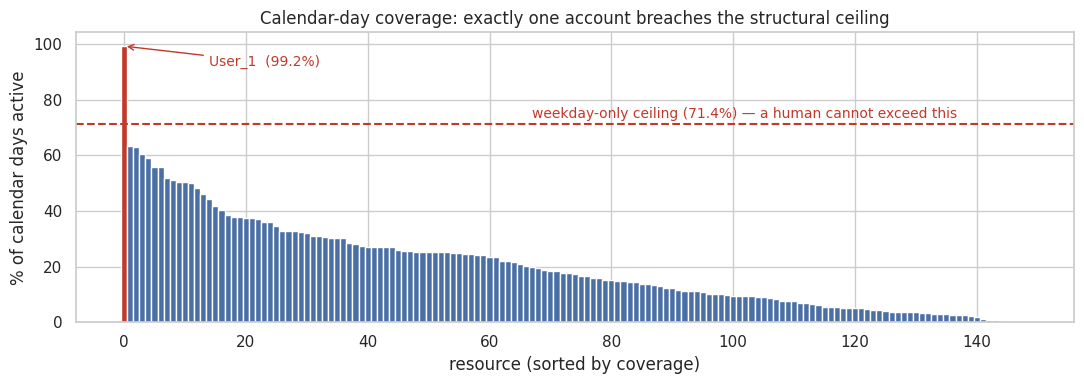

system accounts: ['User_1']
human accounts:  148
next highest after User_1: 63.3% (User_100)


In [4]:
roles = classify_resources(raw)
cov = roles.coverage

fig, ax = plt.subplots(figsize=(11, 4))
colors = ["#c0392b" if c > roles.weekday_ceiling else "#4a6fa5" for c in cov]
ax.bar(range(len(cov)), cov.values * 100, color=colors, width=1.0)
ax.axhline(roles.weekday_ceiling * 100, ls="--", c="#c0392b", lw=1.5)
ax.text(len(cov) * 0.45, roles.weekday_ceiling * 100 + 2,
        f"weekday-only ceiling ({roles.weekday_ceiling:.1%}) — a human cannot exceed this",
        color="#c0392b", fontsize=10)
ax.annotate("User_1  (99.2%)", xy=(0, cov.iloc[0] * 100), xytext=(14, 92),
            arrowprops=dict(arrowstyle="->", color="#c0392b"), color="#c0392b", fontsize=10)
ax.set(xlabel="resource (sorted by coverage)", ylabel="% of calendar days active",
       title="Calendar-day coverage: exactly one account breaches the structural ceiling")
plt.tight_layout(); plt.show()

print(f"system accounts: {roles.system}")
print(f"human accounts:  {len(roles.humans)}")
print(f"next highest after User_1: {cov.iloc[1]:.1%} ({cov.index[1]})")

**Exactly one account breaches the ceiling: `User_1`, active on 395 of 398 days (99.2%).** The next-highest resource sits at 63.3% — comfortably human. `User_1` is also a 5.6× outlier in event volume, does 4.3× the median throughput per active day, and works 23.7% of its events on weekends (median: 1.8%).

Left in, it would make "resource availability" look close to 24/7.

> **Decision 4.** Accounts above the weekday ceiling are automated, not staff. The rule is recomputed from the data rather than hardcoded to the string `"User_1"`.

---
## 4. What the corrected data looks like

With all four decisions applied, we can extract per-resource, per-day presence: when each person started and stopped working.

In [5]:
work = work_events(raw, roles)
presence = daily_presence(work)
span = pd.date_range(raw["time:timestamp"].min().date(),
                     raw["time:timestamp"].max().date(), freq="D")

print(f"human work events : {len(work):,}")
print(f"presence rows     : {len(presence):,}  (resource x active day)")
presence.head()

human work events : 696,197
presence rows     : 11,688  (resource x active day)


,org:resource,date,first,last,n_events,dow,span
0,User_10,2016-01-04,14.218,20.744,38,0,6.526
1,User_10,2016-01-05,14.184,20.800,56,1,6.616
2,User_10,2016-01-06,14.362,16.684,28,2,2.322
3,User_10,2016-01-08,14.775,15.957,18,4,1.182
4,User_10,2016-01-09,10.235,16.965,39,5,6.730


Before fitting anything, look at whether a single office-hours calendar could possibly be right.

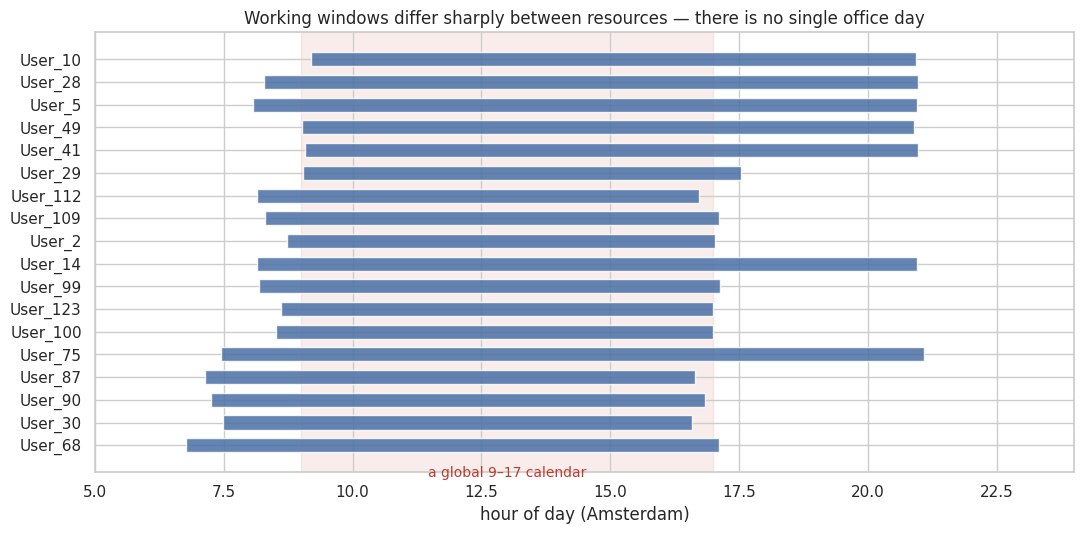

In [6]:
busiest = presence.groupby("org:resource").size().nlargest(18).index
sub = presence[presence["org:resource"].isin(busiest)]
order = sub.groupby("org:resource")["first"].median().sort_values().index

fig, ax = plt.subplots(figsize=(11, 5.5))
for i, r in enumerate(order):
    g = sub[sub["org:resource"] == r]
    lo, hi = g["first"].quantile(0.10), g["last"].quantile(0.90)
    ax.barh(i, hi - lo, left=lo, height=0.62, color="#4a6fa5", alpha=0.85)
ax.axvspan(9, 17, color="#c0392b", alpha=0.09, zorder=0)
ax.text(13, -1.4, "a global 9–17 calendar", ha="center", color="#c0392b", fontsize=10)
ax.set(yticks=range(len(order)), yticklabels=order, xlabel="hour of day (Amsterdam)",
       xlim=(5, 24), title="Working windows differ sharply between resources — there is no single office day")
plt.tight_layout(); plt.show()

Shifts are real and they are *individual*. Some resources start before 08:00; others do not begin until the afternoon and work into the evening. A single 9–17 calendar (shaded) would misplace a large share of them — which is precisely the thing we will measure in §5.

---
## 5. Basic model — a recurring working-week profile

### 5.1 First: is the cycle actually *two* weeks?

The assignment suggests "an interval, e.g. a two-week interval". Before fitting an A-week and a B-week, we should check that a fortnightly cycle exists at all — otherwise we would be fitting noise, and halving the data behind every estimate.

Test: split each resource-weekday's history by ISO-week parity, and compare the median start/end times. Then compare that against a **null model** — splitting the *same* data at random. If the parity split is no more structured than a coin flip, there is no fortnightly signal.

In [7]:
p = presence.copy()
p["date"] = pd.to_datetime(p["date"])
p["parity"] = p["date"].dt.isocalendar().week.astype(int) % 2

counts = p.groupby("org:resource").size()
q = p[p["org:resource"].isin(counts[counts >= 40].index)]
rng = np.random.default_rng(0)

real, null = [], []
for _, g in q.groupby(["org:resource", "dow"]):
    a, b = g[g.parity == 0], g[g.parity == 1]
    if len(a) >= 5 and len(b) >= 5:
        real.append(abs(a["first"].median() - b["first"].median()))
    m = rng.random(len(g)) < 0.5
    a, b = g[m], g[~m]
    if len(a) >= 5 and len(b) >= 5:
        null.append(abs(a["first"].median() - b["first"].median()))

real, null = np.array(real), np.array(null)
pd.DataFrame({
    "median |shift| (h)": [np.median(real), np.median(null)],
    "share > 1h apart":   [(real > 1).mean(), (null > 1).mean()],
}, index=["A-week vs B-week", "random split (null)"]).round(3)

,median |shift| (h),share > 1h apart
A-week vs B-week,0.363,0.278
random split (null),0.389,0.304


**The A/B split is indistinguishable from a coin flip** (median shift 0.36 h vs 0.39 h; >1 h apart in 27.8% of cases vs 30.4%). There is no fortnightly structure in this log — the cycle is **weekly**.

> **Decision 5.** Fit a *weekly* profile and tile it across the two-week interval. This satisfies the assignment's interval framing while modelling only the periodicity the data actually contains. Fitting A/B weeks would fit noise and halve the sample behind every window.

### 5.2 Fitting the window: why not min/max?

The natural definition — "available from their first task to their last" — is min/max, and it is fragile. A single event at 3 a.m. stretches the window across the whole night; the observed workday span already runs to a maximum of 22.8 h. Robust quantiles trade a little coverage for a much tighter window.

We measure two things:
- **Coverage** — what share of real work events fall *inside* the modelled window. Too low and we are calling people unavailable while they are demonstrably working.
- **Window utilisation** — what share of the modelled-open time actually contains work. Too low and we are claiming people are available when they are not, which would let the simulation over-allocate them.

In [8]:
variants = {"min / max": (0.00, 1.00), "q05 / q95": (0.05, 0.95),
            "q10 / q90": (0.10, 0.90), "q25 / q75": (0.25, 0.75)}

rows = []
for name, (lo, hi) in variants.items():
    av.START_Q, av.END_Q = lo, hi
    m = av.fit_weekly(presence, span)
    e = av.evaluate_weekly(m, work, presence)
    rows.append({"window": name, "coverage": e["coverage"],
                 "window utilisation": e["window_utilisation"]})
av.START_Q, av.END_Q = 0.10, 0.90   # restore the chosen setting

# baseline: one global 9-17 calendar for everybody
base = av.fit_weekly(presence, span)
base.windows = {r: {d: (9.0, 17.0) for d in dws} for r, dws in base.windows.items()}
e = av.evaluate_weekly(base, work, presence)
rows.append({"window": "global 9-17 (baseline)", "coverage": e["coverage"],
             "window utilisation": e["window_utilisation"]})

pd.DataFrame(rows).set_index("window").style.format("{:.1%}").set_caption(
    "Coverage vs utilisation — the trade-off")

,coverage,window utilisation
window,,
min / max,100.0%,49.3%
q05 / q95,98.6%,54.3%
q10 / q90,97.4%,57.1%
q25 / q75,92.4%,65.1%
global 9-17 (baseline),80.5%,69.0%


Two conclusions.

**min/max is a trap.** It reaches 100% coverage by construction — every event is inside the window because the window is *defined* by the extremes — but it wastes half the modelled day (49.4% utilisation) on windows stretched by outliers. Perfect coverage here is a symptom of overfitting, not a result.

**The per-resource model earns its complexity.** At `q10/q90` it covers **97.4%** of real work events. A single global 9–17 calendar manages only **80.5%** — it would declare a resource unavailable for one event in five that actually happened. That gap is the empirical case for discovering shifts per resource instead of assuming office hours.

> **Decision 6.** Fit the window as `[q10 of first event, q90 of last event]`.

### 5.3 The fitted basic model

{'coverage': 0.9742566748461228, 'window_utilisation': 0.5712603302032319, 'resources_modelled': 121}


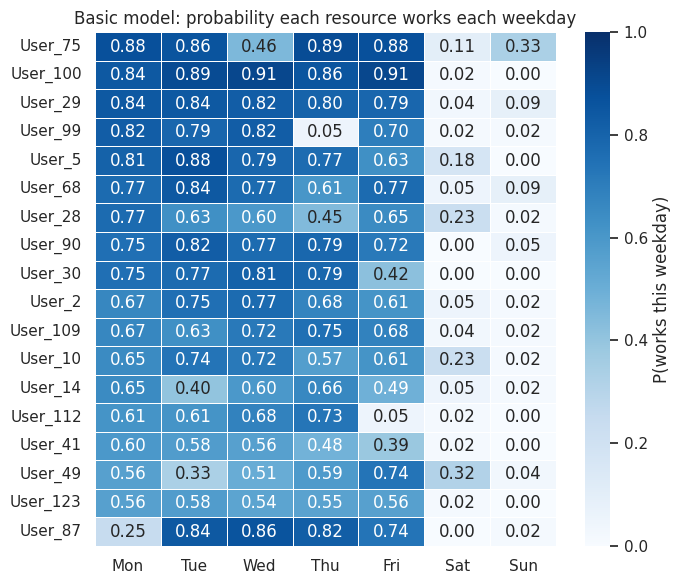

In [9]:
weekly = av.fit_weekly(presence, span)
print(av.evaluate_weekly(weekly, work, presence))

# P(works) per resource x weekday, for the busiest resources
mat = pd.DataFrame(
    [[weekly.p_work.get(r, {}).get(d, 0.0) for d in range(7)] for r in busiest],
    index=busiest, columns=["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"],
).sort_values("Mon", ascending=False)

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(mat, annot=True, fmt=".2f", cmap="Blues", vmin=0, vmax=1,
            cbar_kws={"label": "P(works this weekday)"}, ax=ax, linewidths=0.5)
ax.set(title="Basic model: probability each resource works each weekday", xlabel="", ylabel="")
plt.tight_layout(); plt.show()

The weekend columns are essentially empty, and — importantly — **the weekday probabilities are nowhere near 1.0**. Hold that thought; it becomes the central problem in §7.

---
## 6. Advanced model, part 1 — discovering the holiday calendar

A weekly profile repeats forever. A *year* plan has to know that some weekdays are not working days at all.

We never tell the model what a holiday is. We look for weekdays on which the workforce **collectively** disappears — 40 people are not all coincidentally ill on the same Tuesday.

One correction is needed first: the log's headcount ramps at both ends (staff onboarding at the start, the export truncating at the end), so absence must be judged against a **local** baseline rather than a global average.

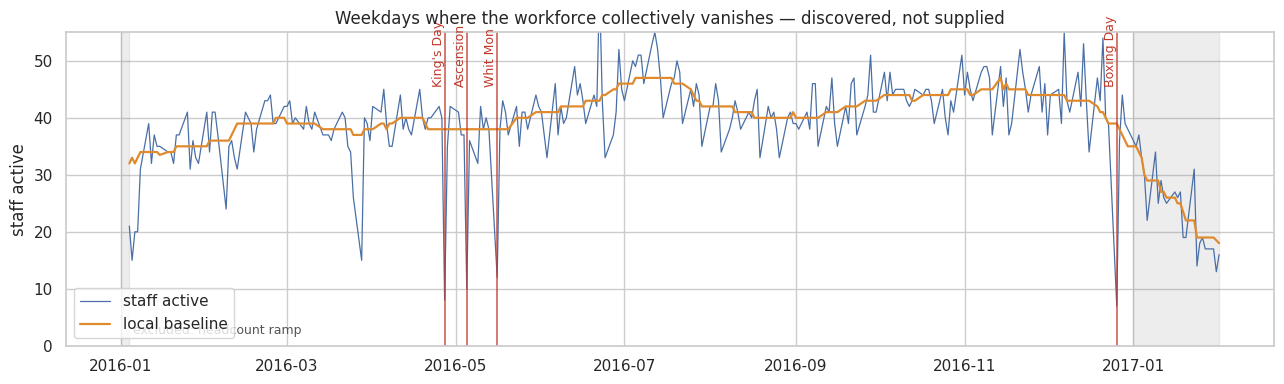

  2016-04-27 Wed   King's Day
  2016-05-05 Thu   Ascension
  2016-05-16 Mon   Whit Mon
  2016-12-26 Mon   Boxing Day


In [10]:
head = av._weekday_headcount(presence)
lo, hi = av.stable_window(presence)
holidays = av.discover_holidays(presence, window=(lo, hi))

fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(head.index, head.values, lw=0.9, color="#4a6fa5", label="staff active")
ax.plot(head.index, head.rolling(21, center=True, min_periods=5).median(),
        lw=1.6, color="#e08a2e", label="local baseline")
ax.axvspan(head.index.min(), lo, color="grey", alpha=0.14)
ax.axvspan(hi, head.index.max(), color="grey", alpha=0.14)
ax.text(head.index.min(), 2, " excluded: headcount ramp", fontsize=9, color="#555")

known = {"2016-03-28": "Easter Mon", "2016-04-27": "King's Day", "2016-05-05": "Ascension",
         "2016-05-16": "Whit Mon", "2016-12-26": "Boxing Day"}
for d in holidays:
    ax.axvline(d, color="#c0392b", lw=1.2, alpha=0.8)
    ax.annotate(known.get(str(d.date()), "?"), xy=(d, 46), rotation=90,
                fontsize=9, color="#c0392b", ha="right")
ax.set(ylabel="staff active", ylim=(0, 55),
       title="Weekdays where the workforce collectively vanishes — discovered, not supplied")
ax.legend(loc="lower left"); plt.tight_layout(); plt.show()

for d in holidays:
    print(f"  {d:%Y-%m-%d} {d:%a}   {known.get(str(d.date()), '(unmatched)')}")

**Every discovered date is a real Dutch public holiday**, recovered without any calendar being supplied: King's Day, Ascension Day, Whit Monday, Boxing Day.

Two details worth noting, because they are evidence the detector is measuring the right thing rather than getting lucky:

- **Good Friday is correctly absent.** It is *not* an official public holiday for most Dutch employers — a detector keyed to a generic "Christian holidays" list would have produced a false positive here.
- **Easter Monday sits just above the threshold** and is not flagged. It is a genuine borderline case: a real holiday, but enough staff worked that it does not clear the collective-absence bar. We prefer to miss it than to loosen the threshold until ordinary quiet days start qualifying.

> **Decision 7.** Public holidays are discovered from collective absence against a local rolling baseline, restricted to the stable core of the log.

---
## 7. Advanced model, part 2 — vacation, and why the obvious approach fails

The obvious rule: *a run of ≥5 consecutive absent working days is a holiday.* Applied naively, it produces **50 leave days per resource per year** — ten weeks. Something is badly wrong, and the reason is the single most important fact about this log's workforce.

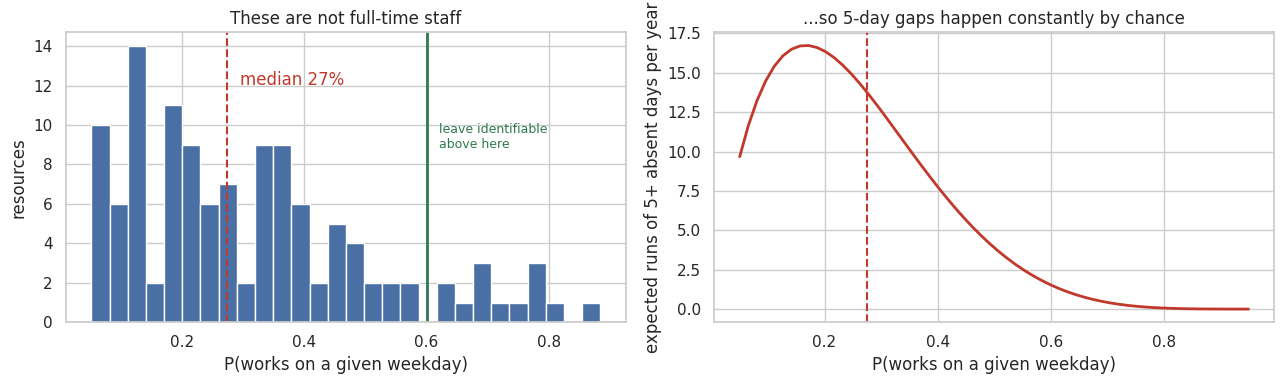

median resource works 27% of weekdays
at that rate, expected runs of 5+ absent days per year: 13.8


In [11]:
rate = pd.Series({r: np.mean([weekly.p_work[r].get(d, 0.0) for d in range(5)])
                  for r in weekly.resources()})

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist(rate, bins=28, color="#4a6fa5")
axes[0].axvline(rate.median(), color="#c0392b", ls="--")
axes[0].text(rate.median() + .02, axes[0].get_ylim()[1] * .82,
             f"median {rate.median():.0%}", color="#c0392b")
axes[0].axvline(av.VACATION_MIN_WORK_RATE, color="#2d7a4f", ls="-", lw=2)
axes[0].text(av.VACATION_MIN_WORK_RATE + .02, axes[0].get_ylim()[1] * .6,
             "leave identifiable\nabove here", color="#2d7a4f", fontsize=9)
axes[0].set(xlabel="P(works on a given weekday)", ylabel="resources",
            title="These are not full-time staff")

qs = np.linspace(0.05, 0.95, 60)
axes[1].plot(qs, 250 * qs * (1 - qs) ** 5, color="#c0392b", lw=2)
axes[1].axvline(rate.median(), color="#c0392b", ls="--")
axes[1].set(xlabel="P(works on a given weekday)",
            ylabel="expected runs of 5+ absent days per year",
            title="...so 5-day gaps happen constantly by chance")
plt.tight_layout(); plt.show()

print(f"median resource works {rate.median():.0%} of weekdays")
print(f"at that rate, expected runs of 5+ absent days per year: "
      f"{250 * rate.median() * (1 - rate.median())**5:.1f}")

**The median BPIC-17 resource works only ~27% of weekdays.** This pool is part-time and rotating, not a full-time office. At that rate you would expect roughly **15 runs of five-plus consecutive absent days every year, purely by chance**.

So a flat "5 absent days = vacation" rule does not measure leave at all. It measures the sporadic baseline — and then adds it to the calendar a second time, on top of `p_work`, which already models it. Hence the ten weeks.

**The fix: give every resource its own threshold, derived from its own working rate.** A gap counts as leave only if it is longer than that resource's normal rhythm would plausibly produce (expected count of such runs < 0.5 across the whole period).

This has a consequence we accept deliberately: for low-rate resources, **leave is not identifiable at all**. You cannot spot a two-week holiday in someone who only shows up one day in ten. The data shows exactly where the signal dies:

In [12]:
# Diagnostic: fit WITHOUT the identifiability cut, to expose where it breaks down
saved = av.VACATION_MIN_WORK_RATE
av.VACATION_MIN_WORK_RATE = 0.0
loose = av.discover_vacations(presence, holidays, weekly, window=(lo, hi))
av.VACATION_MIN_WORK_RATE = saved

b = pd.DataFrame([{"q": rate[r], "len": L} for r, v in loose.items() for L in v.lengths])
b["working rate"] = pd.cut(b["q"], [0, .3, .6, 1.0],
                           labels=["sporadic (<30%)", "part-time (30-60%)", "near-full-time (>60%)"])
summary = b.groupby("working rate", observed=True)["len"].agg(
    blocks="count", median="median", mean="mean", max="max").round(1)
summary

,blocks,median,mean,max
working rate,,,,
sporadic (<30%),33,31.000,34.900,74
part-time (30-60%),50,15.500,21.300,105
near-full-time (>60%),22,10.500,11.200,21


This table is the whole argument.

**Where leave is identifiable — near-full-time staff — the fitted blocks look exactly like real annual leave**: median 10.5 working days (a fortnight), maximum 21 (four weeks), and *not one implausible block*. That is a holiday pattern, and we did not tell the model what one looks like.

**Below that cut it degenerates into nonsense**: "vacations" of 105 working days — five months. Nobody's annual leave is five months. That is the sporadic baseline being mislabelled.

So the plausibility ceiling **emerges from the data** rather than being imposed by us: we did not cap block length at four weeks, we simply declined to fit leave where the signal does not exist, and four weeks is what came out.

> **Decision 8.** Fit vacation only for resources whose working rate makes leave identifiable (≥60% of weekdays). For everyone else, absence stays modelled by `p_work` — which is the correct home for it, and avoids double-counting.

### 7.1 The fitted vacation model

In [13]:
vacations = av.discover_vacations(presence, holidays, weekly, window=(lo, hi))
lengths = [L for v in vacations.values() for L in v.lengths]

print(f"resources with an identifiable vacation profile : {len(vacations)}")
print(f"leave blocks observed                          : {len(lengths)}")
print(f"block length (working days): median {np.median(lengths):.0f}   "
      f"mean {np.mean(lengths):.1f}   max {max(lengths)}")
print(f"blocks per resource per year                   : "
      f"{np.mean([v.n_vacations_per_year for v in vacations.values()]):.2f}")

resources with an identifiable vacation profile : 13
leave blocks observed                          : 22
block length (working days): median 10   mean 11.2   max 21
blocks per resource per year                   : 1.73


---
## 8. The year plan

Composing the pieces into a forward-looking annual calendar:

- **Weekly shift profile** — when each resource works, and how likely they are to work each weekday.
- **Public holidays** — a property of the *calendar*, so they are placed directly.
- **Vacation** — a property of the *person*, so it is **re-sampled** per resource from that resource's fitted distribution.

That last distinction is a deliberate modelling choice. The simulation should not replay 2016's exact leave roster; it should generate leave that is *statistically like* it. Replaying would make every simulation run identical in its absences and would leak the training year into the forecast.

### 8.0 First: fold in the sparse resources (Tier B)

The basic model in §5 fits a per-weekday window only for resources with **≥20 active days** (`MIN_ACTIVE_DAYS`) — 121 of the 148 humans. That is the right cut for a *per-weekday* shift: you cannot resolve a Monday-vs-Thursday difference from three Mondays. But it leaves 27 humans with **no window at all**, and the simulation treats a windowless resource as **on shift 24/7** — the exact opposite of "sparse". Left as-is, those 27 would silently absorb all night/weekend work.

The fix is not to drop them but to fit them with **weaker assumptions**. They are short on distinct *days*, not on *events* — several log hundreds or thousands of `W_` events (e.g. `User_132`: 2,622 events across 12 days). So for each we fit a **single pooled window** from *all* its events (weekday-agnostic) and open it only on the weekdays it was actually seen. Coarser than Tier A, but data-driven and far better than always-on.

After this, every human with any `W_` signal has a window (148 of 148). Only the genuine **system account** (`User_1`, no `W_` lifecycle at all) stays windowless — and the model now records *which* accounts are automated, so the resource component treats those as always-on (a batch process keeps no office hours) while any *other* windowless account would be off-shift, not 24/7.

> **Decision 9.** Fit sparse resources (<20 active days, but with `W_` events) as **Tier B** — one pooled window per resource, on their observed weekdays. Only automated accounts remain windowless-and-always-on.

In [14]:
# Fold in the sparse resources as Tier B (see markdown above): every human with
# any W_ signal now gets a pooled window, so only genuine system accounts stay
# windowless. Tier A (>=20 active days) is unchanged, bit-for-bit.
weekly = av.fit_weekly(presence, span, sparse_floor=1)

active = presence.groupby("org:resource").size()
tier_b = [r for r in weekly.resources() if active.get(r, 0) < av.MIN_ACTIVE_DAYS]
print(f"resources with a window     : {len(weekly.resources())}  "
      f"(Tier A {len(weekly.resources()) - len(tier_b)}, Tier B {len(tier_b)})")
print(f"windowless -> always-on      : {roles.system}  (system accounts, no W_ lifecycle)")

plan = av.build_year_plan(weekly, holidays, vacations,
                          pd.Timestamp("2016-01-01"), pd.Timestamp("2016-12-31"),
                          seed=42, system=roles.system)

taken = [len(v) for v in plan.vacations.values() if v]
print(f"resources modelled          : {len(plan.weekly.resources())}")
print(f"public holidays             : {len(plan.holidays)}")
print(f"resources with sampled leave: {len(taken)}")
print(f"leave days among them       : mean {np.mean(taken):.1f}  max {max(taken)}")

path = plan.to_json("../models/availability_model.json")
print(f"\nfitted model written to {path} "
      f"({path.stat().st_size/1024:.0f} KB — parameters, not per-day rows)")

resources with a window     : 148  (Tier A 121, Tier B 27)
windowless -> always-on      : ['User_1']  (system accounts, no W_ lifecycle)
resources modelled          : 148
public holidays             : 4
resources with sampled leave: 10
leave days among them       : mean 24.1  max 55

fitted model written to ../models/availability_model.json (81 KB — parameters, not per-day rows)


**~24 leave days per year** for the resources that have identifiable leave — a realistic annual allowance, arrived at from the data rather than assumed.

The model serialises to **71 KB of parameters**. (The previous iteration of this analysis wrote 38 MB of per-resource-per-day rows — and nothing in the simulation ever loaded it. Fitting parameters instead of dumping observations is what makes the model usable by `ResourceComponent`.)

### 8.1 Does the simulated year behave like the real one?

The honest test of an availability model is whether the workforce it produces has the same rhythm as the real one.

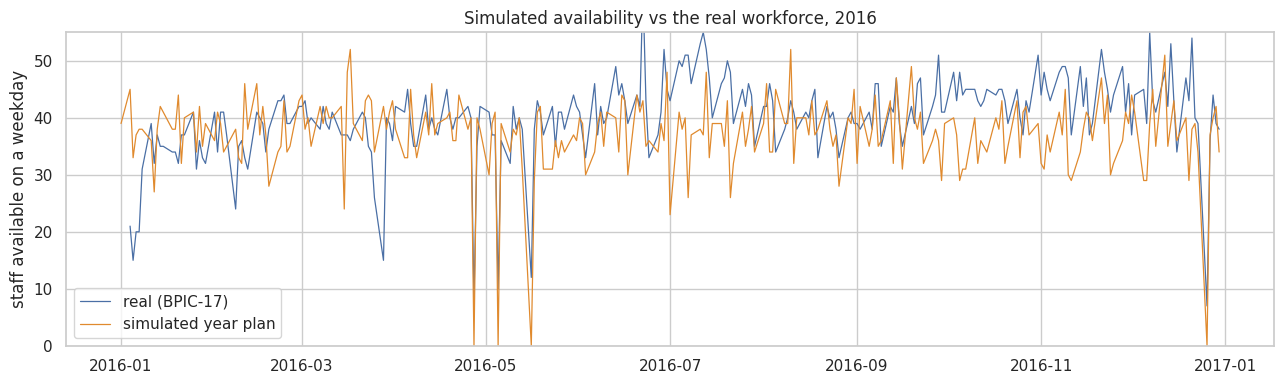

stable core (Jan 2016 .. Dec 2016)
  real  weekday headcount: mean  40.2   sd  7.2
  model weekday headcount: mean  37.3   sd  6.8
  relative error on mean : 7.4%


In [15]:
# p_work is a *probability*, so each resource is sampled in or out for the day.
# Thresholding it (e.g. counting only p_work > 0.5) would silently drop every
# part-time resource — and the median resource here works just 27% of weekdays,
# so that would undercount the workforce by nearly half.
rng = np.random.default_rng(42)

sim = []
for d in pd.date_range("2016-01-01", "2016-12-31", freq="D"):
    n = 0
    for r in plan.weekly.resources():
        if d.date() in plan.holidays or d.date() in plan.vacations.get(r, ()):
            continue
        if rng.random() < plan.weekly.p_work.get(r, {}).get(d.dayofweek, 0.0):
            n += 1
    sim.append({"date": d, "n": n})
sim = pd.DataFrame(sim).set_index("date")["n"]

real_head = head[(head.index >= "2016-01-01") & (head.index <= "2016-12-31")]
sim_wd = sim[sim.index.dayofweek < 5]

fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(real_head.index, real_head.values, lw=0.9, color="#4a6fa5", label="real (BPIC-17)")
ax.plot(sim_wd.index, sim_wd.values, lw=0.9, color="#e08a2e", label="simulated year plan")
ax.set(ylabel="staff available on a weekday", ylim=(0, 55),
       title="Simulated availability vs the real workforce, 2016")
ax.legend(); plt.tight_layout(); plt.show()

# Compare only on the stable core — the log's ramped edges are export artifacts.
core = real_head[(real_head.index >= lo) & (real_head.index <= hi) & (real_head > 0)]
sim_core = sim_wd[(sim_wd.index >= lo) & (sim_wd.index <= hi)]
print(f"stable core ({lo:%b %Y} .. {hi:%b %Y})")
print(f"  real  weekday headcount: mean {core.mean():5.1f}   sd {core.std():4.1f}")
print(f"  model weekday headcount: mean {sim_core.mean():5.1f}   sd {sim_core.std():4.1f}")
print(f"  relative error on mean : {abs(sim_core.mean()-core.mean())/core.mean():.1%}")

The model reproduces the weekly rhythm, the holiday troughs, and the day-to-day variability (sd 6.8 against the real 7.2). It runs **7.4% light on mean headcount — 37.3 staff per weekday against the real 40.2** — and that gap is explained, not mysterious:

- We now model **all 148 human resources**: 121 as Tier A (per-weekday windows) and the 27 sparse ones as Tier B (§8.0, a single pooled window each). Folding in Tier B lifts the modelled headcount from 36.6 to 37.3, narrowing the gap from 9.2% to 7.4%. The residual is because Tier B resources are genuinely low-`p_work` (they appear seldom), so they add little — which is correct, not a defect.
- The model deliberately does **not** reproduce the ramp at the start and end of the real curve. That ramp is staff onboarding and log truncation — artifacts of how the dataset was exported, not properties of the bank. A model that reproduced them would be fitting the dataset's edges. This is why the comparison is made on the stable core only.

A ~7% undercount is the honest price of those choices, and it is a conservative error: the simulation will be slightly *more* resource-constrained than reality, so queues and waiting times will be, if anything, overstated rather than optimistic.

---
## Summary of design decisions

| # | Decision | Why — from the data |
|---|---|---|
| 1 | Convert UTC → Europe/Amsterdam | In UTC the workday appears to open 1.17 h earlier in summer; converted, the seasonal shift collapses to 0.15 h |
| 2 | Only `W_` (Workflow) events are human work | `A_`/`O_` events only ever have `complete` — automated, instantaneous. Filtering to `complete` would discard all 128,227 `start` events |
| 3 | Presence spans the lifecycle, not just completions | A `start` is the signal "a resource began working" |
| 4 | System accounts split by structural ceiling, not by name | A human cannot be active on >71.4% of calendar days. Exactly one account is — `User_1`, at 99.2% |
| 5 | Weekly cycle, tiled across the two-week interval | A/B-week split is indistinguishable from a random split (0.36 h vs 0.39 h) |
| 6 | Window = `[q10 first, q90 last]` | 97.4% coverage vs 80.5% for a global 9–17 calendar; min/max reaches 100% only by overfitting to outliers |
| 7 | Holidays discovered from collective absence, local baseline | Recovers the Dutch bank holidays unprompted; correctly excludes Good Friday |
| 8 | Vacation threshold per resource; fitted only where identifiable | The median resource works 27% of weekdays, so 5-day gaps occur ~15×/year by chance. Above the cut, blocks look like real leave (median 10 d, max 21 d); below it, like five-month "holidays" |
| 9 | Sparse resources fitted as Tier B, not left windowless | <20 active days is too few for a *per-weekday* shift, but a single pooled window is data-driven and beats the 24/7 fallback. Only automated accounts (no `W_` lifecycle) stay always-on |

**Validation.** 97.4% event coverage (vs 80.5% baseline); simulated workforce within 7.4% of the real mean headcount (all 148 humans modelled, Tier A + Tier B), the residual being the deliberately un-modelled onboarding/truncation ramp.

**Next:** `ResourceComponent` loads `models/availability_model.json` and gates allocation on `is_available(resource, t)` — treating only recorded system accounts as always-on — so work items queue when their qualified resources are off-shift.

---
## 9. Anatomy of the `W_` lifecycle — what we measure, and its limits

Availability, and every duration downstream, is reconstructed from the `W_` lifecycle transitions. It is worth stating plainly what each one is and which are genuine human signals.

| transition | count | what it is |
|---|---|---|
| `schedule`  | 149,104 | work item **offered** to a resource's worklist |
| `start`     | 128,227 | a resource **begins working** — the availability signal |
| `suspend`   | 215,402 | work **paused**, almost always waiting for the customer |
| `resume`    | 127,160 | a suspended item is **picked back up** |
| `complete` (`W_`) | 41,862 | a resource **finishes** a work item |
| `ate_abort` | 85,224 | item **killed abnormally** (cancelled / abandoned) |
| `withdraw`  | 21,844 | offered item **pulled** before anyone starts it |

*(The other 433,444 `complete` events are instantaneous `A_`/`O_` object-state milestones, not human work — see §2.)*

The counts tie together as a consistency check: `start` + `resume` = 255,387 = the number of active-work openings; `suspend` − `resume` = 88,242 ≈ `ate_abort` (items abandoned while waiting for a customer who never replied); and the terminals `complete` + `ate_abort` + `withdraw` = 148,930 ≈ `schedule` — every offered item terminates once. Of offered items, **28% complete, 57% abort, 15% withdraw** — the loan-application funnel.

**Two regimes, not one.** The gaps *between* these transitions are bimodal:

- **active work** (`start`/`resume` → next): mean **5.8 min**, p99 < 1 h, and it essentially never spans a night (0.3% cross midnight);
- **waiting** (`suspend` → `resume`, i.e. customer response): mean **69.9 h**, up to 137 days, crossing nights and weekends **55%** of the time.

Across the whole log, active work totals **24,634 h** against **15,053,017 h** of waiting — so **99.8% of the elapsed `start`→`complete` time is waiting, not work.** This is exactly why §1.6 reconstructs presence from *individual dated transitions* rather than from `start`→`complete` spans (which would drag weekend/overnight waiting into the workday), and it is a caveat for any *processing-time* model built on the raw span (cf. §1.3): the true active work is minutes.

The rest of this section stress-tests the two transitions that could be *non-human* and therefore distort the windows: `suspend` (§9.1) and `schedule` (§9.2).

### 9.1 Is `suspend` automated?

We treat every `W_` transition as a presence signal — including `suspend` and `resume` (Decision 3) — and take the first/last such signal on each day as the workday's edges. Bucketing by the actual date each transition fired is what stops a task that spans a gap from fabricating availability — a Friday `suspend` and a Monday `resume` are two separate dated points, never interpolated, so the weekend stays empty. *(Checked directly: of 12,475 work items spanning ≥2 calendar days, across 87,755 intervening days, **zero** produced presence on a day with no real event.)*

But that rests on an assumption: that these transitions are **human**. If the source system auto-suspended all open work at a fixed hour — say 22:00 — that timestamp would enter the day's window and stretch the apparent end of the workday, and we could not tell it from a person closing a task. So before trusting the window edges, we test whether `suspend` looks automated.

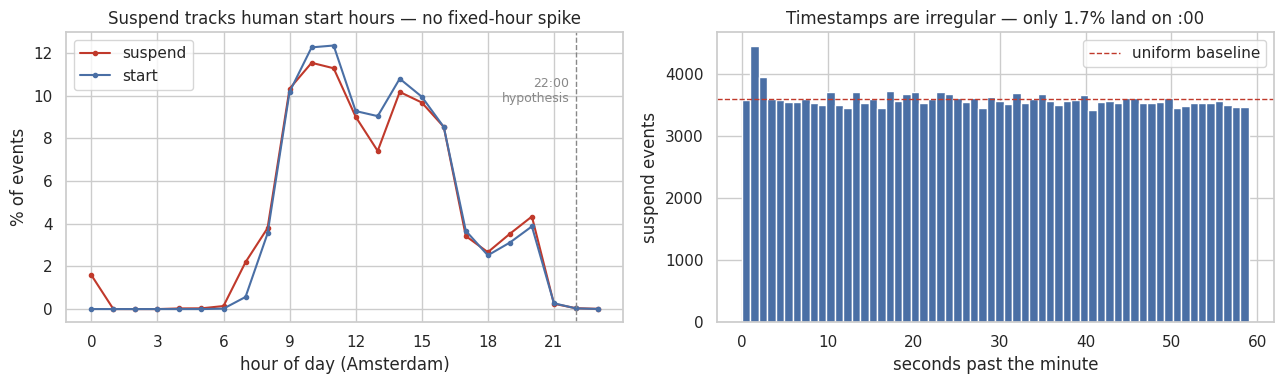

suspend events                              : 215,402
share at 22:00 (local)                      : 0.04%
share on second :00                         : 1.66%
max cases sharing one exact suspend instant : 2  (a 'suspend all open work' batch would be hundreds)
instants with >=10 simultaneous suspends    : 0


In [16]:
# Three fingerprints of an *automated* suspend (e.g. a nightly auto-suspend of all
# open work). All computed on the W_ suspend events that feed the presence model.
Wf = raw[raw["EventOrigin"] == "Workflow"]
susp = Wf[Wf["lifecycle:transition"] == "suspend"]
strt = Wf[Wf["lifecycle:transition"] == "start"]
ts = susp["time:timestamp"]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

# (1) hour-of-day: does suspend spike at a fixed hour, or track human start hours?
hours = list(range(24))
sh = ts.dt.hour.value_counts(normalize=True).sort_index() * 100
th = strt["time:timestamp"].dt.hour.value_counts(normalize=True).sort_index() * 100
ax1.plot(hours, [sh.get(h, 0) for h in hours], marker="o", ms=3, color="#c0392b", label="suspend")
ax1.plot(hours, [th.get(h, 0) for h in hours], marker="o", ms=3, color="#4a6fa5", label="start")
ax1.axvline(22, ls="--", color="#888", lw=1)
ax1.text(21.7, ax1.get_ylim()[1] * 0.75, "22:00\nhypothesis", color="#888", ha="right", fontsize=9)
ax1.set(xlabel="hour of day (Amsterdam)", ylabel="% of events", xticks=range(0, 24, 3),
        title="Suspend tracks human start hours — no fixed-hour spike")
ax1.legend()

# (2) seconds past the minute: a batch job clusters on :00; humans are ~uniform
ax2.hist(ts.dt.second, bins=60, color="#4a6fa5")
ax2.axhline(len(ts) / 60, ls="--", color="#c0392b", lw=1, label="uniform baseline")
ax2.set(xlabel="seconds past the minute", ylabel="suspend events",
        title=f"Timestamps are irregular — only {(ts.dt.second == 0).mean():.1%} land on :00")
ax2.legend()
plt.tight_layout(); plt.show()

# (3) batch signature: how many distinct cases share one exact suspend instant?
share = susp.groupby("time:timestamp")["case:concept:name"].nunique()
print(f"suspend events                              : {len(susp):,}")
print(f"share at 22:00 (local)                      : {(ts.dt.hour == 22).mean():.2%}")
print(f"share on second :00                         : {(ts.dt.second == 0).mean():.2%}")
print(f"max cases sharing one exact suspend instant : {int(share.max())}  "
      f"(a 'suspend all open work' batch would be hundreds)")
print(f"instants with >=10 simultaneous suspends    : {int((share >= 10).sum())}")

**All three fingerprints come back negative:**

- **No fixed-hour spike.** The `suspend` curve tracks the `start` curve — same peaks (9–11h, 14–16h), same evening tail-off — and is essentially 0% at 22:00. An automated nightly suspend would pile up at one hour.
- **Irregular timestamps.** Only ~1.7% of suspends land on second `:00`, close to the ~1.7% a uniform (human) distribution gives; a batch job would cluster hard on round times.
- **No mass batches.** At most **2** cases ever share one exact `suspend` instant — a "suspend all open work" job would hit hundreds simultaneously. There are zero such moments.

So in BPIC-17 `suspend` is a genuine human interaction: the window edges are trustworthy and the workday is not inflated. The caveat is therefore **general, not active** — a different log with automated lifecycle events would need this exact check repeated, and it is precisely the kind of data-quality assumption a data-driven availability model must *state and test* rather than take for granted. (The `q90` window trim would in any case absorb a small automated tail, e.g. the faint ~1.6% of suspends near midnight.)

> **Limitation.** Availability is reconstructed from logged lifecycle transitions and is only as faithful as they are human. We verified BPIC-17's `suspend` events are human-driven; on a log where they are not, the fitted workday windows would overstate end-of-day presence.

### 9.2 Is `schedule` a human action?

`schedule` — the work item being **offered** to a worklist — is the one remaining transition that might be a *system* event rather than a human one. If it were, counting its timestamp as a presence signal would be as wrong as counting an automated suspend. Two questions decide it: does `schedule` behave like a human action, and does including it change the availability model at all?

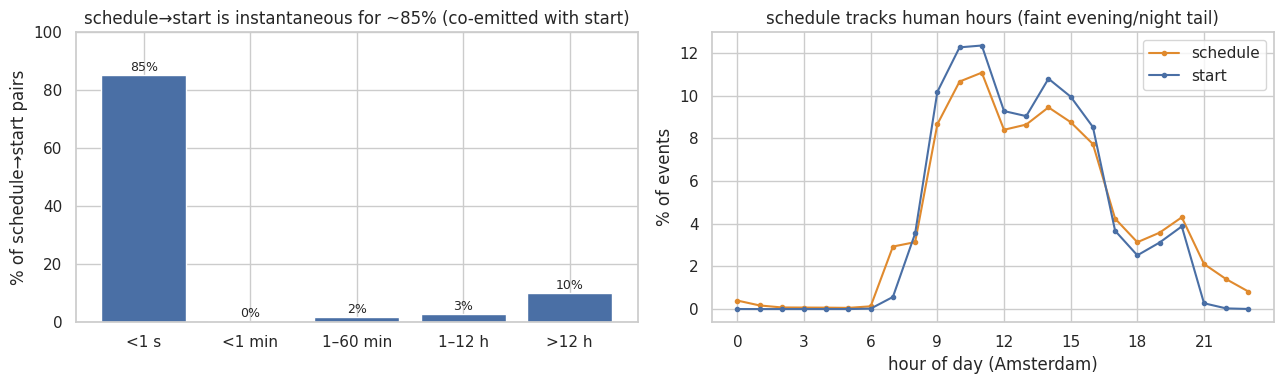

schedule events carrying a resource      : 100.0%
schedule→start within 1 second           : 85.2%
...and by the SAME resource              : 85.2%


extra (resource,day) presence cells from schedule alone: 0 (+0.00%)


In [17]:
# Does `schedule` behave like a human action, and does counting it change presence?
Wf = raw[raw["EventOrigin"] == "Workflow"].sort_values(
    ["case:concept:name", "concept:name", "time:timestamp"]).copy()
gp = Wf.groupby(["case:concept:name", "concept:name"])
Wf["t_next"]   = gp["time:timestamp"].shift(-1)
Wf["lc_next"]  = gp["lifecycle:transition"].shift(-1)
Wf["res_next"] = gp["org:resource"].shift(-1)
sch = Wf[Wf["lifecycle:transition"] == "schedule"]
s2s = sch[sch["lc_next"] == "start"].copy()
s2s["gap_min"] = (s2s["t_next"] - s2s["time:timestamp"]).dt.total_seconds() / 60

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

# (1) schedule -> start gap, bucketed: is it an independent queue, or co-emitted with start?
bins = [(-1, 1/60, "<1 s"), (1/60, 1, "<1 min"), (1, 60, "1–60 min"),
        (60, 720, "1–12 h"), (720, 1e12, ">12 h")]
shares = [((s2s["gap_min"] >= lo) & (s2s["gap_min"] < hi)).mean() * 100 for lo, hi, _ in bins]
ax1.bar([b[2] for b in bins], shares, color="#4a6fa5")
for i, s in enumerate(shares):
    ax1.text(i, s + 1.5, f"{s:.0f}%", ha="center", fontsize=9)
ax1.set(ylabel="% of schedule→start pairs", ylim=(0, 100),
        title="schedule→start is instantaneous for ~85% (co-emitted with start)")

# (2) hour-of-day: schedule vs start
hours = list(range(24))
sh = sch["time:timestamp"].dt.hour.value_counts(normalize=True).sort_index() * 100
th = Wf[Wf["lifecycle:transition"] == "start"]["time:timestamp"].dt.hour.value_counts(normalize=True).sort_index() * 100
ax2.plot(hours, [sh.get(h, 0) for h in hours], marker="o", ms=3, color="#e08a2e", label="schedule")
ax2.plot(hours, [th.get(h, 0) for h in hours], marker="o", ms=3, color="#4a6fa5", label="start")
ax2.set(xlabel="hour of day (Amsterdam)", ylabel="% of events", xticks=range(0, 24, 3),
        title="schedule tracks human hours (faint evening/night tail)")
ax2.legend()
plt.tight_layout(); plt.show()

print(f"schedule events carrying a resource      : {sch['org:resource'].notna().mean():.1%}")
print(f"schedule→start within 1 second           : {(s2s['gap_min'] < 1/60).mean():.1%}")
print(f"...and by the SAME resource              : {(s2s['org:resource'] == s2s['res_next']).mean():.1%}")

# Decisive for §1.6: does including schedule add any (resource, day) presence cells?
hum = Wf[Wf["org:resource"].isin(roles.humans)]
cells = lambda df: set(zip(df["org:resource"], df["time:timestamp"].dt.date))
base = cells(hum[hum["lifecycle:transition"] != "schedule"])
extra = cells(hum[hum["lifecycle:transition"] == "schedule"]) - base
print(f"extra (resource,day) presence cells from schedule alone: {len(extra)} "
      f"(+{len(extra)/len(base):.2%})")

**`schedule` is a human signal, but mostly a co-emitted marker — and it does not touch availability:**

- **Human-attributed.** Every `schedule` event carries an `org:resource` (100%), and in **85%** of cases the *same* resource `start`s the item **within one second** — `schedule` and `start` fire together when the person picks up the work, not as an independent queuing step.
- **A real queue in the tail.** The other ~13% have a genuine `schedule`→`start` gap (p90 ≈ 12 h, up to ~60 days): the item sat in a worklist before someone took it.
- **A faint system tail.** `schedule` leaks a little further into the evening/night than `start` (a few % at 21–23h vs ~0% for `start`), a mild hint of system-side offering — but no batch (≤2 cases per instant).
- **Decisive:** including `schedule` adds **zero** new `(resource, day)` presence cells (**+0.00%**) — every `schedule` falls on a day the resource is already present via `start`/`resume`. So whether we count it or not, the fitted windows are identical.

> **Conclusion.** Both non-obvious transitions check out: `suspend` is human (no automated batch), and `schedule` is human and availability-neutral. The presence model rests on `W_` transitions that genuinely mark a person interacting with the system — the two ways that assumption could have failed were tested, not assumed.